In [1]:
import pickle
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
parent_normal = "./04_2025_enahncers/"
parent_aggregate_path = "./04_2025_enahncers/agregate/"

In [3]:
cell_types = ['Astrocytes',
 'Chat Neurons',
 'Endothelial Cells',
 'Ependymal Cells',
 'Excitatory Neurons',
 'Fibroblasts',
 'Inhibitory Neurons',
 'Microglia',
 'Mural Cells',
 'Oligodendrocyte Precursor Cells',
 'Oligodendrocytes']

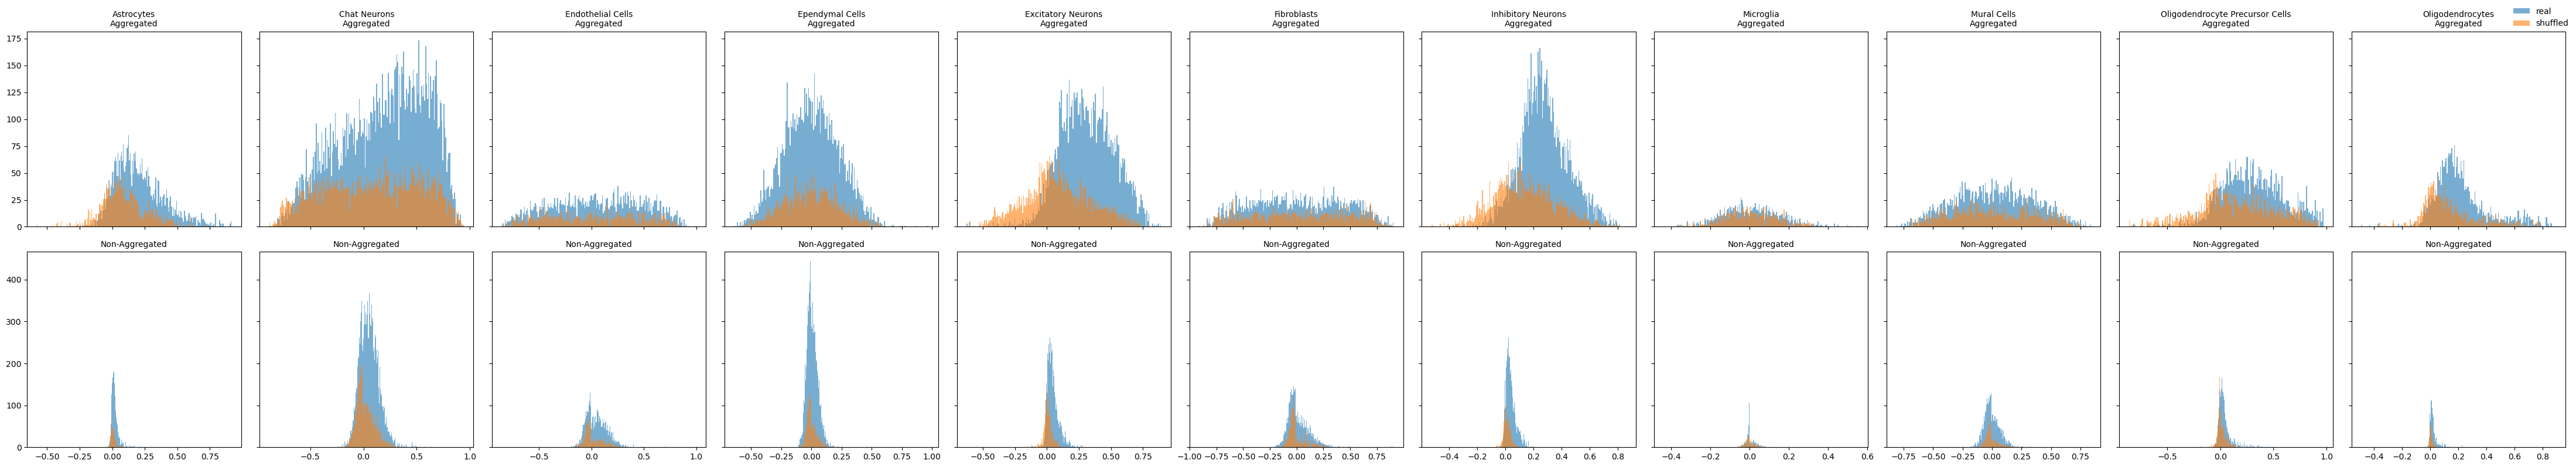

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(cell_types),
    figsize=(4 * len(cell_types), 8),
    sharex='col',
    sharey='row'
)

for i, cell_type in enumerate(cell_types):
    agg_path = os.path.join(parent_aggregate_path, cell_type)
    norm_path = os.path.join(parent_normal, cell_type)

    files = {
        "agg_cons"      : agg_path  + "_cons.pickle",
        "agg_shuffle"   : agg_path  + "_shuffled_cons.pickle",
        "cons"          : norm_path + "_cons.pickle",
        "cons_shuffle"  : norm_path + "_shuffled_cons.pickle",
    }

    with open(files["agg_cons"], "rb")      as f: agg_cons      = pickle.load(f)
    with open(files["agg_shuffle"], "rb")   as f: agg_shuffle   = pickle.load(f)
    with open(files["cons"], "rb")          as f: cons          = pickle.load(f)
    with open(files["cons_shuffle"], "rb")  as f: cons_shuffle  = pickle.load(f)

    ax = axes[0, i]
    ax.hist(agg_cons["RNA_Correlations"],      bins=200, alpha=0.6, label="real")
    ax.hist(agg_shuffle["RNA_Correlations"],   bins=200, alpha=0.6, label="shuffled")
    ax.set_title(f"{cell_type}\nAggregated", fontsize=10)

    ax = axes[1, i]
    ax.hist(cons["RNA_Correlations"],          bins=200, alpha=0.6)
    ax.hist(cons_shuffle["RNA_Correlations"],  bins=200, alpha=0.6)
    ax.set_title("Non-Aggregated", fontsize=10)

# put one legend for the whole figure (upper-right)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
